# Assignment 3: Linear Models

In [10]:
! git clone https://github.com/arya-rajesh-99/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?


1. A linear model is has linear coefficients, meaning the outcome is expressed as a linear combination of variables even if those variables are transformed.
2. The  dummy/one-hot-encoded variable converts a qualitative variable into a numeric expression. The coefficient of the model is the difference between a group and the omitted baseline. The intercept shows the mean fo the baseline group.
3. Linear regression can be used for classification but it is not the most accurate because some predictd values do not fall within the range of probabilities of the model. The regression is often sensitive to outliers and works better for data that has a linear trend.
4. A linear model is overfitting if the model performs well for the training data but not well on test/validation data. Additionally, multicolinearity often leads to overfitting because more variabels often improve fit but also reduces performance on test.
5. Multicollinearity is the tendency of highly correlated variables to cancel each other out which gives the model an unexpected high variance quality. In a two-stage approach, if you regress one variable on the others and get a high fit, it indicates multicollinearity, meaning the model cannot clearly separate their individual effects. Regressing one variable on others and resulting in high fit makes it difficult to isolate individual variable effects.
6. Nonlinear relationships can be included by adding transformations of variables, while keeping the model linear in coefficients.
7. The slope coefficient in a linear regression is the change in the outcome variable associated with a one-unit increase in the predictor. This is while holding other variables constant.
8. A train-test split divides the data once into training and testing sets. On the other hand, the k-fold cross validation repeatedly splits the data into k parts and averages performance across them, providing a more reliable estimate than a train-test split. Also, the cross validation gives a more efficient way to split the data without performing the more lengthy train-test split.
9. The k in the kfold cross validation is picked by common variance. The model wants to increase variability and reduce reliability by taking a very small set of neighbors from which to make predictions.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [11]:
# used Q1_clean.csv and uploaded as recommended by the email from prof
airbnb_df = pd.read_csv('./Q1_clean.csv')
airbnb_df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


Neighbourhood 
Manhattan        183.664286
Staten Island    146.166667
Brooklyn         127.747378
Queens            96.857233
Bronx             75.276498
Name: Price, dtype: float64


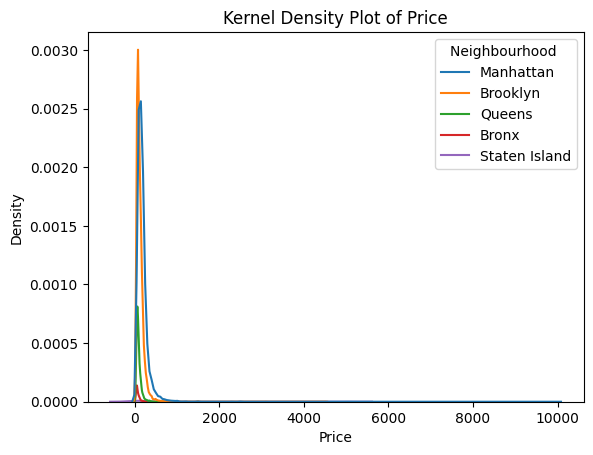

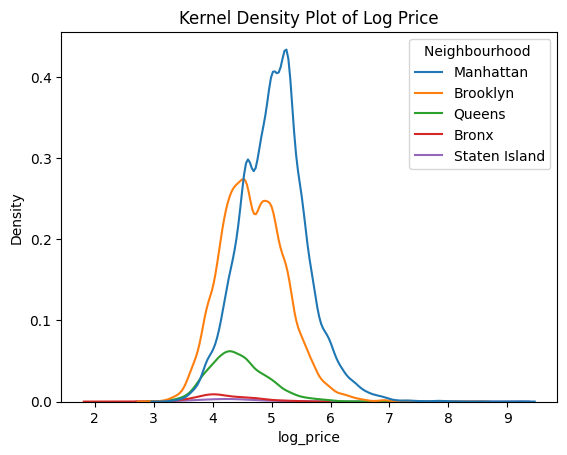

In [13]:
# Question 2.1
airbnb_df.dtypes
#converting price to num
airbnb_df["Price"] = (
    airbnb_df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
airbnb_df["Price"] = pd.to_numeric(airbnb_df["Price"], errors="coerce")
#review score to num
airbnb_df["Review Scores Rating"] = pd.to_numeric(
    airbnb_df["Review Scores Rating"], errors="coerce"
)
#grouping
neighbourhood_avg = airbnb_df.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print(neighbourhood_avg['Price'].sort_values(ascending=False))

#price kde plot
sns.kdeplot(data=airbnb_df, x="Price", hue="Neighbourhood ")
plt.title('Kernel Density Plot of Price')
plt.show()
#log price kde plot
airbnb_df['log_price'] = np.log(airbnb_df['Price'])
sns.kdeplot(data=airbnb_df, x="log_price", hue="Neighbourhood ")
plt.title('Kernel Density Plot of Log Price')
plt.show()

 Most expensive on average is Manhattan.


In [14]:
# Question 2.2
from sklearn.linear_model import LinearRegression
tdf = airbnb_df.loc[:, ['Price', 'Neighbourhood '] ].dropna()
y = tdf['Price']
X_neighbor = pd.get_dummies(tdf['Neighbourhood '], drop_first=True)
model = LinearRegression()
model.fit(X_neighbor, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


Intercept is the mean price of ommitted neibourhood since drop_first is true.
Each coefficient is the difference from that neighborhood. So the mean is the sum of the two.

In [ ]:
# Question 2.3
tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating'] ].dropna()
y = tdf['Price']
X_num = tdf[['Review Scores Rating']]
model = LinearRegression()
model.fit(X_num, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: 60.878390657123546


,variable,coefficient
0,Review Scores Rating,1.020827


The slope coefficient means that for every one point increase in the review score rating, there is a 1.02084371 dollar change in price per night.

In [15]:
# Question 2.4
tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating', 'Neighbourhood ']].dropna()
y = tdf['Price']
X_num = tdf.loc[:, ['Review Scores Rating']]
X_neighbor = pd.get_dummies(tdf['Neighbourhood '], dtype='int', drop_first=True)
X = pd.concat([X_num, X_neighbor], axis=1)
model = LinearRegression()
model = model.fit(X, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: -23.812561011673324


,variable,coefficient
0,Review Scores Rating,1.081116
1,Brooklyn,51.704240
2,Manhattan,108.228737
3,Queens,21.694600
4,Staten Island,71.766552


The slope coefficient changes to review score rating while maintaining constant neighborhood category. The neighborhood averages show coefficients which are adjusted differences instead of raw mean.

In [16]:
# Question 2.5
tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating', 'Neighbourhood ']].dropna()
y = tdf['Price']
X_num = tdf.loc[:, ['Review Scores Rating']]
X_neighbor = pd.get_dummies(tdf['Neighbourhood '], dtype='int', drop_first=True)
X = pd.concat([X_num, X_neighbor], axis=1)
for col in X_neighbor.columns:
    X[col + ' Review Scores Rating'] = X_neighbor[col] * tdf['Review Scores Rating']
model = LinearRegression()
model = model.fit(X, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: 22.63838492209186


,variable,coefficient
0,Review Scores Rating,0.574311
1,Brooklyn,-16.392990
2,Manhattan,41.315429
3,Queens,28.259701
4,Staten Island,2963.071040
5,Brooklyn Review Scores Rating,0.741165
6,Manhattan Review Scores Rating,0.729703
7,Queens Review Scores Rating,-0.072294
8,Staten Island Review Scores Rating,-31.831748


The slope on Review Scores Rating differs across neighbourhoods because additional variables are included that modify the slope. This slope for review scores rating is 0.574. The slopes are not equal across neighbourhoods as shown by the table.

In [17]:
# Question 2.6
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating', 'Neighbourhood ']].dropna()
y = tdf['Price']
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
model = LinearRegression()
# Q2.3
X = tdf[['Review Scores Rating']]
scores3 = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Q2.3 Mean:", np.mean(scores3))
# Q2.4
X = pd.concat([tdf[['Review Scores Rating']],
               pd.get_dummies(tdf['Neighbourhood '], dtype='int', drop_first=True)], axis=1)
scores4 = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Q2.4 Mean:", np.mean(scores4))
# Q2.5
X_neighbor = pd.get_dummies(tdf['Neighbourhood '], dtype='int', drop_first=True)
X = pd.concat([tdf[['Review Scores Rating']], X_neighbor], axis=1)
for col in X_neighbor.columns:
    X[col + ' Review Scores Rating'] = X_neighbor[col] * tdf['Review Scores Rating']
scores5 = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Q2.5 Mean:", np.mean(scores5))

Q2.3 Mean: 22079.512358769138
Q2.4 Mean: 21074.09738730938
Q2.5 Mean: 21334.75481329511


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


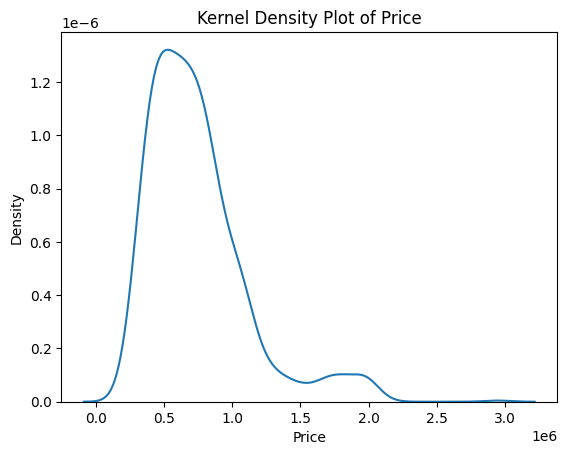

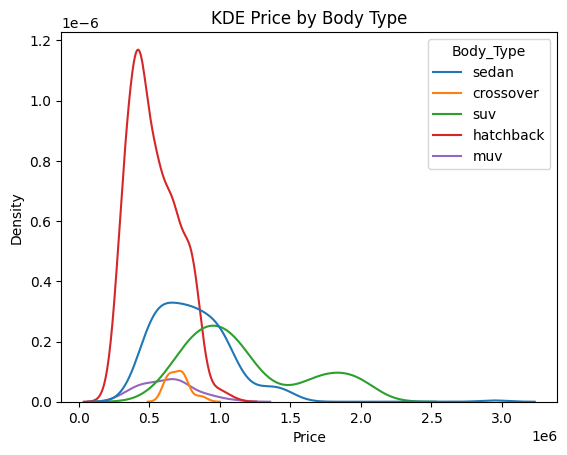

In [18]:
# question 3.1
cars_df = pd.read_csv('./data/cars_hw.csv')
cars_df.head()

#summarizing price
cars_df['Price'].describe()
sns.kdeplot(data=cars_df, x="Price")
plt.title('Kernel Density Plot of Price')
plt.show()

#groupby and describe
cars_df.groupby('Body_Type')['Price'].describe()
sns.kdeplot(data=cars_df, x="Price", hue="Body_Type")
plt.title('KDE Price by Body Type')
plt.show()

SUV cars are the most expensive and SUV cars and sedans have the most variance. This is seen in the second KDE plot as SUV have the most right shifted price for highest density. SUV and sedans have the most variance for price as they both vary around 2.3 and 1.8 e^6 dollars respectively.

In [19]:
# question 3.2
# slope coeffcieint for price on seating capacity regression
tdf = cars_df.loc[:, ['Price', 'Seating_Capacity']].dropna()
y=tdf['Price']
X_num = tdf[['Seating_Capacity']]
model = LinearRegression()
model.fit(X_num, y)

print('Model Intercept', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
    })

Model Intercept 439032.0141018266


,variable,coefficient
0,Seating_Capacity,59267.998037


The slope coefficient is 59267.998037. This means that there is an increase by one seat for a change of 59267.998037 rupees in price.

In [22]:
# question 3.2 continued
#seating capacity as categorical
tdf = cars_df.loc[:, ['Price', 'Seating_Capacity']].dropna()
y=tdf['Price']
X_cat = pd.get_dummies(tdf['Seating_Capacity'], dtype='int', drop_first=True)

model = LinearRegression()
model.fit(X_cat, y)
print('Model Intercept', model.intercept_)
pd.DataFrame({
    'variable': X_cat.columns, #had to do columns so it works, no error
    'coefficient': model.coef_
})

Model Intercept 188000.00000000314


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


The differences in price are roughly linear in number of seats. The first regression model shows a positive slope meaning that price and seating capacity have a direct relationship. The categorical model shows that the prices are increasing with number of seats in categories.

In [25]:
#question 3.3
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import numpy as np

cars_df['Age'] = cars_df['Make_Year'].max() - cars_df['Make_Year']
tdf = cars_df.loc[:, ['Price', 'Age']].dropna()
y = tdf['Price']
# cross validation
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
degrees = range(1, 11)
mse_list = []
for d in degrees:
    X = PolynomialFeatures(degree=d, include_bias=False).fit_transform(tdf[['Age']])
    model = LinearRegression()
    scores = cross_val_score(
        model, X, y,
        cv=kfold,
        scoring='neg_mean_squared_error'
    )

    scores = -scores
    mse_list.append(np.mean(scores))

# results
cv_results = pd.DataFrame({
    'degree': list(degrees),
    'mse': mse_list
})

# optimal degree
optimal_degree = cv_results.loc[cv_results['mse'].idxmin(), 'degree']

print(cv_results)
print("optimal:", optimal_degree)

   degree           mse
0       1  9.759399e+10
1       2  9.778877e+10
2       3  9.718282e+10
3       4  9.665715e+10
4       5  9.573421e+10
5       6  9.592860e+10
6       7  9.539459e+10
7       8  9.441435e+10
8       9  9.397699e+10
9      10  9.406251e+10
optimal: 9


Cross validation shows the optimal number is 9 as the degree with the lowest average mean squared error.

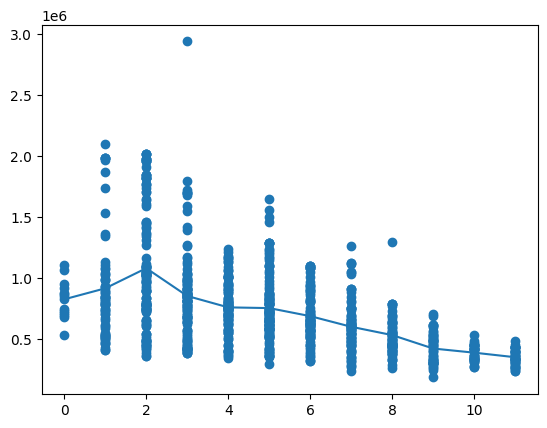

In [26]:
# question 3.4
tdf = cars_df.loc[:, ['Price', 'Age']].dropna().sort_values('Age')
y = tdf['Price']
X = tdf[['Age']]
poly=PolynomialFeatures(degree=int(optimal_degree), include_bias=False)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)
tdf['predicted_price'] = model.predict(X_poly)
#plotting
plt.scatter(tdf['Age'], tdf['Price'])
plt.plot(tdf['Age'], tdf['predicted_price'])
plt.show()


The model shows the overall inverse relationship between price and age but it is not an accurate fit because the variation in prices are not shown.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [29]:
# loaded the heart_hw.csv manually as suggested in the prof email
heart_df = pd.read_csv('./heart_hw.csv')
heart_df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [30]:
# question 4.1
# Regress y on transplant
group_survival = heart_df.groupby('transplant')['y'].mean()
print(group_survival)

ATE = group_survival['treatment'] - group_survival['control']
print(ATE)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
0.23017902813299232


The ATE on three-year survival for heart transplant interventions is approximately 0.230. The proportion who survive in the control group is approximately
0.118. The proportion who survive in the treatment group is approximately 0.348.


In [33]:
# question 4.2
tdf = heart_df.loc[:, ['y', 'transplant']].dropna()
y = tdf['y']
X_num = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)
model = LinearRegression()
model.fit(X_num, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': X_num.columns,
    'coefficient': model.coef_
})

Model Intercept: 0.1176470588235293


,variable,coefficient
0,treatment,0.230179


The intercept, as the mean survival probability for control, is approximately 0.118. The coefficient of treatment, as the difference in survival between the treatment and control groups, is approximately 0.230. Both values are consistent from part 1 as the proportion for control(0.118) and ATE (0.230) are the same values for intercept and coefficient respectively.


In [34]:
#question 4.3
# Regress y on transplant and age
tdf = heart_df.loc[:, ['y', 'transplant', 'age']].dropna()

y = tdf['y']
X_num = tdf[['age']]
X_transplant = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)
X = pd.concat([X_num, X_transplant], axis=1)
model = LinearRegression()
model.fit(X, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
})

Model Intercept: 0.7019569721740946


,variable,coefficient
0,age,-0.013607
1,treatment,0.264702


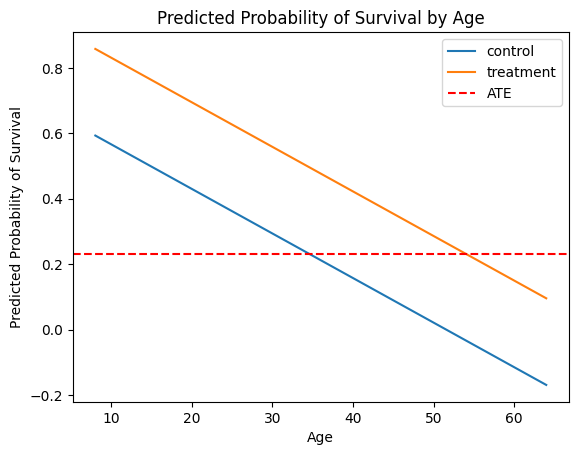

In [35]:
#question 4.3 (cont)

# plot
#plotting age. used framework from the linear models notes but also had to look
# up how to use the np.linspace and np.zeroes, np.ones functions
age_grid = pd.DataFrame({
    'age': np.linspace(tdf['age'].min(), tdf['age'].max(), 100)
})
X_control = pd.concat([
    age_grid,
    pd.DataFrame({'treatment': np.zeros(len(age_grid), dtype='int')})
], axis=1)
X_treat = pd.concat([
    age_grid,
    pd.DataFrame({'treatment': np.ones(len(age_grid), dtype='int')})
], axis=1)
yhat_control = model.predict(X_control)
yhat_treat = model.predict(X_treat)

plt.plot(age_grid['age'], yhat_control, label='control')
plt.plot(age_grid['age'], yhat_treat, label='treatment')
plt.axhline(ATE, linestyle='--', label='ATE', color='red')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.title('Predicted Probability of Survival by Age')
plt.legend()
plt.show()

The intercept, approximately 0.702 shows the predicted probability of survival for the control group when age is held at zero. The coefficient, approx -0.0136, is the change in survival probability with an increase of age by one while transplant is constant. When age is controlled, the coefficient on transplant increases to approximately 0.265 which is lower than the ATE of 0.230. This means that age is a variable that affects transplant and survival relation as a confounding/unpredicted variable.

The plot shows that the ATE underestimates the effect of a transplant at younger ages (ages around 0-35 years) and overestimates the effect at older ages(>35 years).

In [36]:
#question 4.4
#  include transplant, age, and transplant * age as controls.
tdf = heart_df.loc[:, ['y', 'transplant', 'age']].dropna()
y = tdf['y']
X_num = tdf[['age']]
X_transplant = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)
X = pd.concat([X_num, X_transplant], axis=1)

for col in X_transplant.columns:
    X[col + ' age'] = X_transplant[col] * tdf['age']

model = LinearRegression()
model.fit(X, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
})

Model Intercept: 0.35486517529946177


,variable,coefficient
0,age,-0.005524
1,treatment,0.907751
2,treatment age,-0.014591


In [37]:
#prediction
age_grid = pd.DataFrame({
    'age': np.linspace(tdf['age'].min(), tdf['age'].max(), 100)
})

X_control = pd.DataFrame({
    'age': age_grid['age'],
    'treatment': np.zeros(len(age_grid), dtype='int'),
    'treatment age': np.zeros(len(age_grid))
})

X_treat = pd.DataFrame({
    'age': age_grid['age'],
    'treatment': np.ones(len(age_grid), dtype='int'),
    'treatment age': age_grid['age']
})

yhat_control = model.predict(X_control)
yhat_treat = model.predict(X_treat)

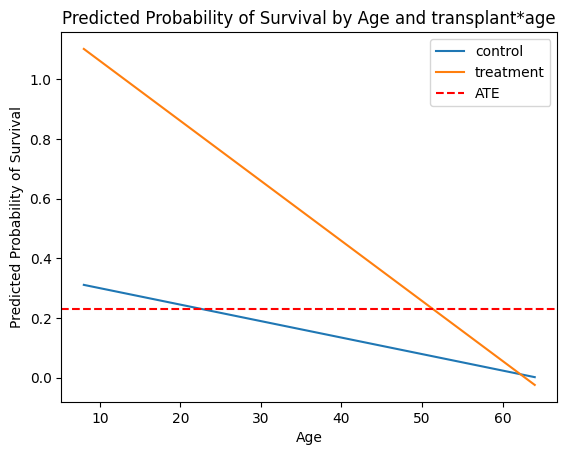

In [38]:
#plot
plt.plot(age_grid['age'], yhat_control, label='control')
plt.plot(age_grid['age'], yhat_treat, label='treatment')
plt.axhline(ATE, linestyle='--', label='ATE', color='red')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.title('Predicted Probability of Survival by Age and transplant*age')
plt.legend()
plt.show()

Allowing age and transplant to interact means that the effect of a transplant varies with age rather than being constant.
The transplant value varies with age because it is no longer constant. The coefficient on interaction, approx -0.0146, shows the effect of a transplant decreases as age increases (inverse). The intercept, approx 0.355, shows predicted survival probability for control group at the age of zero. For control, the age coefficient (-0.0055) shows survival probability decreases with age.
The lines intersect in this plot compared to the other graph which had parallel lines. This means that the transplant is likely more impactful for younger individuals than older.

In [39]:
# question 4.5
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

tdf = heart_df.loc[:, ['y', 'transplant', 'age']].dropna()
y = tdf['y']
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
model = LinearRegression()
# model 1
X = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)
scores1 = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Model 1 Mean:", np.mean(scores1))
# model 2
X = pd.concat([tdf[['age']], pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)], axis=1)
scores2 = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Model 2 Mean:", np.mean(scores2))
# model 3
X_transplant = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)
X = pd.concat([tdf[['age']], X_transplant], axis=1)
for col in X_transplant.columns:
    X[col + ' age'] = X_transplant[col] * tdf['age']
scores3 = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Model 3 Mean:", np.mean(scores3))

Model 1 Mean: 0.19366383979017968
Model 2 Mean: 0.18171967184387972
Model 3 Mean: 0.18067090272965322


If this model is used to prioritize transplant access then there are concerns that treatment assignment isn't random. The model could attribute the transplant effect on who receives and doesn't receive the transplant. Also, the model may be biased and not fully accurate, so using it to decide who gets a transplant could lead to unfair or incorrect decisions which is a concern on deployment. The approximation is also based from a data set which simplifies the approximations given by the model.